# DCS-404: AI & ML Final Capstone Project
# Prediction of Daily Electricity Usage in Global Data Centers

**Instructor:** Siman Giri
**Course:** DCS404 – Artificial Intelligence and Machine Learning

**Team Members:**
1. Amrita Pudasaini
2. Safola Bhattarai
3. Shreya Tiwari

---

## Acknowledgement / Dataset Source
Dataset: **Global Data Center & AI Water/Electricity Usage (2019–2025)**, by Ashutosh Singh, sourced from Kaggle:
https://www.kaggle.com/datasets/ashyou09/global-data-center-and-ai-waterelectricity-usage

Libraries used: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`. All are publicly available open-source libraries, used here in accordance with course guidelines.

---

# Part 1: Problem Definition

### Dataset
The dataset contains **126,770 records** describing **18,110 global data center facilities** tracked from **2019 to 2025**. It includes facility metadata (location, type, owner), technical specifications (capacity, cooling system, PUE), and consumption metrics (electricity and water usage).

### Machine Learning Task
This is a **Regression** task — we are predicting a continuous numeric value: `Daily_Electricity_Usage_MWh`.

### Input Features
| Feature | Type | Description |
|---|---|---|
| `Year` | Numeric | Calendar year (2019–2025) |
| `Facility_Type` | Categorical | Enterprise/Standard, Colocation, Hyperscale/AI |
| `Estimated_Capacity_MW` | Numeric | Rated power capacity in megawatts |
| `PUE` | Numeric | Power Usage Effectiveness (efficiency ratio) |
| `Cooling_System_Type` | Categorical | Air Cooled, Evaporative, Liquid Cooled |
| `Country` | Categorical | Country of operation (344 unique values) |
| `Surrounding_Water_Stress_Tier` | Categorical | Low / Medium / High water stress in the region |

### Target Variable
**`Daily_Electricity_Usage_MWh`** — the amount of electricity (in Megawatt-hours) a facility consumes per day.

### Problem Objective
To build and compare three regression models — **Linear Regression**, **Ridge Regression**, and **Random Forest Regressor** — that predict a data center's daily electricity consumption from its physical and operational characteristics. Accurate prediction supports energy-demand forecasting, grid planning, and sustainability research as AI and cloud computing infrastructure expands globally.


---
# Setup: Import Libraries

We import all libraries needed across the entire project: data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn` — used throughout EDA as required), and modeling/evaluation tools from `scikit-learn`.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully.")


All libraries imported successfully.


---
# Part 2: Data Exploration and Preprocessing

## 2.1 Exploratory Data Analysis (EDA)

### Load dataset and inspect structure


In [2]:
df = pd.read_csv('data_center_hybrid.csv')

print("Number of instances (rows)   :", df.shape[0])
print("Number of features (columns) :", df.shape[1])
print()
print("Column names and data types:")
print(df.dtypes)


Number of instances (rows)   : 126770
Number of features (columns) : 14

Column names and data types:
Year                               int64
Facility_ID                          str
Facility_Name                        str
Owner_Company                        str
City                                 str
Country                              str
Facility_Type                        str
Estimated_Capacity_MW            float64
PUE                              float64
Cooling_System_Type                  str
WUE_L_per_kWh                    float64
Daily_Electricity_Usage_MWh      float64
Daily_Water_Usage_Gallons        float64
Surrounding_Water_Stress_Tier        str
dtype: object


In [3]:
df.head()


,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


**Observation:** The dataset has 126,770 rows and 14 columns. Columns include facility identifiers (text), categorical descriptors (Facility_Type, Cooling_System_Type, Country, Water_Stress_Tier), and numeric measurements (Year, Capacity, PUE, Electricity Usage, Water Usage). The target column `Daily_Electricity_Usage_MWh` is numeric (float64), confirming this is a regression problem.

### Summary statistics

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Year,126770.0,2022.000000,2.000008,2019.000,2020.0000,2022.000,2024.0000,2025.00
Estimated_Capacity_MW,126770.0,23.075117,45.847195,1.000,5.4500,9.870,14.1800,562.89
PUE,126770.0,1.637746,0.190833,1.057,1.5180,1.643,1.7870,2.00
WUE_L_per_kWh,126770.0,0.820596,0.925481,0.001,0.1390,0.232,1.6540,3.00
Daily_Electricity_Usage_MWh,126770.0,605.222368,1040.061940,22.190,167.4325,302.750,451.3700,14812.66
Daily_Water_Usage_Gallons,126770.0,131218.164755,397962.899982,224.010,4840.5375,12181.295,75730.6825,7585092.35


**Observation:** `Estimated_Capacity_MW` ranges widely (small edge sites to massive hyperscale campuses), and `Daily_Electricity_Usage_MWh` similarly spans a very wide range with a much larger mean than median — an early sign of right-skew, which we visualize below. `PUE` values cluster close to 1.0–2.0, consistent with real-world data center efficiency ratios.

### Missing or invalid values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", missing.sum())
print("Duplicate rows:", df.duplicated().sum())

# Check for invalid values (e.g. negative or zero where it shouldn't be)
print("\nMinimum values for key numeric columns:")
print(df[['Estimated_Capacity_MW', 'PUE', 'Daily_Electricity_Usage_MWh']].min())


Missing values per column:
Year                             0
Facility_ID                      0
Facility_Name                    0
Owner_Company                    0
City                             0
Country                          0
Facility_Type                    0
Estimated_Capacity_MW            0
PUE                              0
Cooling_System_Type              0
WUE_L_per_kWh                    0
Daily_Electricity_Usage_MWh      0
Daily_Water_Usage_Gallons        0
Surrounding_Water_Stress_Tier    0
dtype: int64

Total missing values: 0


Duplicate rows: 0

Minimum values for key numeric columns:
Estimated_Capacity_MW           1.000
PUE                             1.057
Daily_Electricity_Usage_MWh    22.190
dtype: float64


**Observation:** There are **zero missing values** and **zero duplicate rows** — the dataset is already clean. All minimum values for capacity, PUE, and electricity usage are positive, confirming no invalid (negative/zero) readings that would need correction.

### Distribution of the target variable

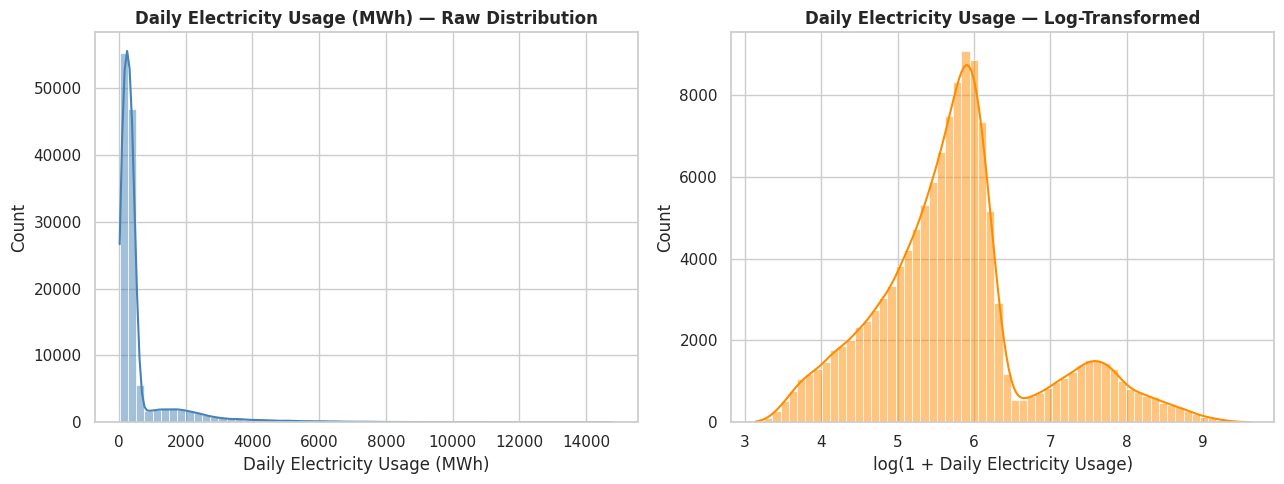

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['Daily_Electricity_Usage_MWh'], bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Daily Electricity Usage (MWh) — Raw Distribution', fontweight='bold')
axes[0].set_xlabel('Daily Electricity Usage (MWh)')

sns.histplot(np.log1p(df['Daily_Electricity_Usage_MWh']), bins=60, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Daily Electricity Usage — Log-Transformed', fontweight='bold')
axes[1].set_xlabel('log(1 + Daily Electricity Usage)')

plt.tight_layout()
plt.show()


**Observation:** The target variable is strongly **right-skewed**: most facilities consume a moderate amount of electricity, while a smaller number of very large (hyperscale) facilities pull the distribution's tail far to the right. The log-transformed view confirms a roughly log-normal shape, common for physical/economic quantities of this kind.

### Box plot: target variable by Facility Type (outlier inspection)

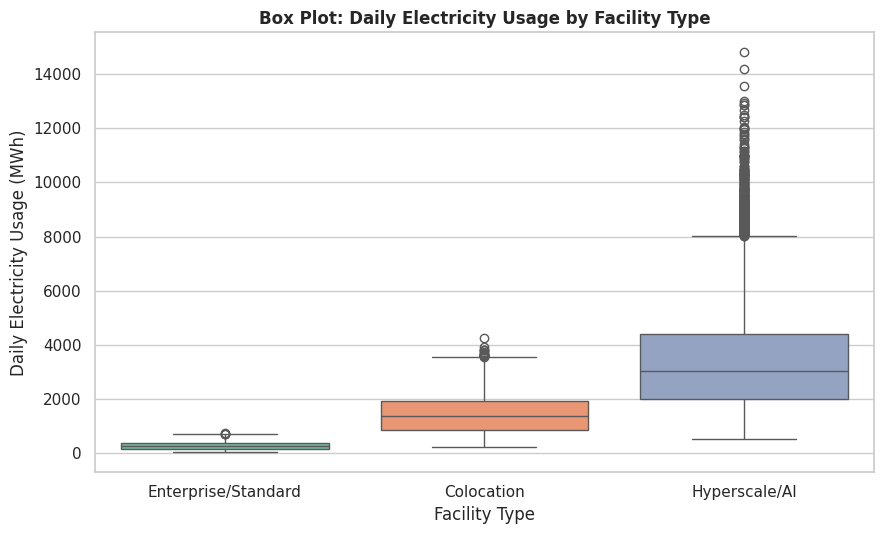

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x='Facility_Type', y='Daily_Electricity_Usage_MWh', ax=ax, palette='Set2')
ax.set_title('Box Plot: Daily Electricity Usage by Facility Type', fontweight='bold')
ax.set_ylabel('Daily Electricity Usage (MWh)')
ax.set_xlabel('Facility Type')
plt.tight_layout()
plt.show()


**Observation:** The box plot reveals clear separation between facility types. **Hyperscale/AI** facilities have the highest median electricity usage and widest spread, with many high-value outliers (the dots above the whiskers) — these are the very largest AI training/cloud campuses. **Enterprise/Standard** facilities show the lowest median and tightest interquartile range. **Colocation** sits in between. This confirms `Facility_Type` strongly differentiates electricity consumption and the outliers are legitimate, not data errors — they represent real hyperscale facilities.

### Box plot: PUE by Cooling System Type

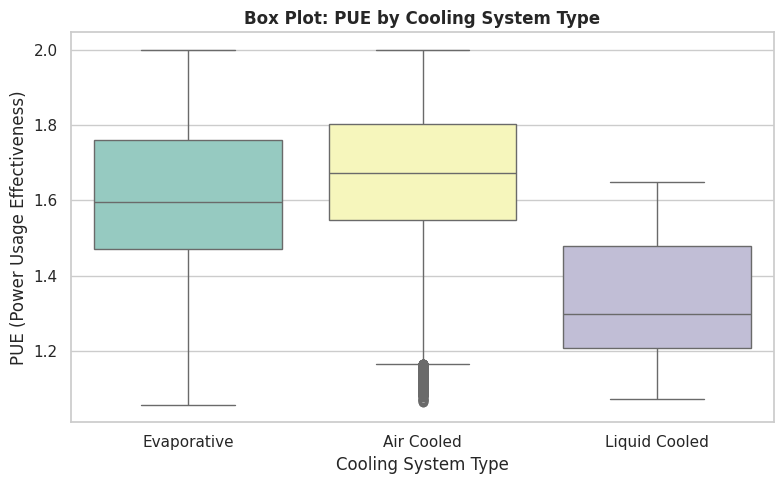

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Cooling_System_Type', y='PUE', ax=ax, palette='Set3')
ax.set_title('Box Plot: PUE by Cooling System Type', fontweight='bold')
ax.set_ylabel('PUE (Power Usage Effectiveness)')
ax.set_xlabel('Cooling System Type')
plt.tight_layout()
plt.show()


**Observation:** Cooling system type visibly shifts the PUE distribution. **Liquid Cooled** systems tend toward lower, tighter PUE values (more efficient), while **Air Cooled** systems show a higher median PUE (less efficient, more energy overhead per unit of IT load). This relationship matters because PUE is itself a strong driver of total electricity consumption.

### Count plots for categorical variables

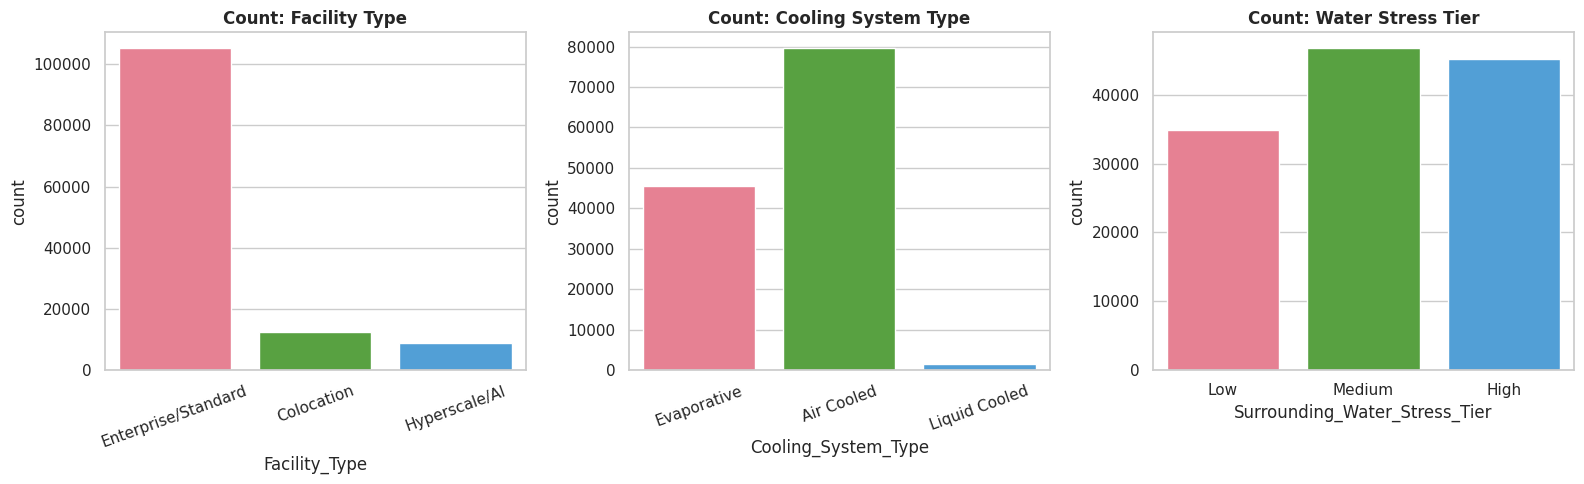

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='Facility_Type', ax=axes[0], palette='husl')
axes[0].set_title('Count: Facility Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='Cooling_System_Type', ax=axes[1], palette='husl')
axes[1].set_title('Count: Cooling System Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='Surrounding_Water_Stress_Tier', ax=axes[2],
              order=['Low', 'Medium', 'High'], palette='husl')
axes[2].set_title('Count: Water Stress Tier', fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** The three categorical features are reasonably balanced across their categories (no extreme class imbalance), meaning the model will see ample examples of every category during training and is unlikely to be biased toward a single dominant class.

### Scatter plots: relationships among numeric features

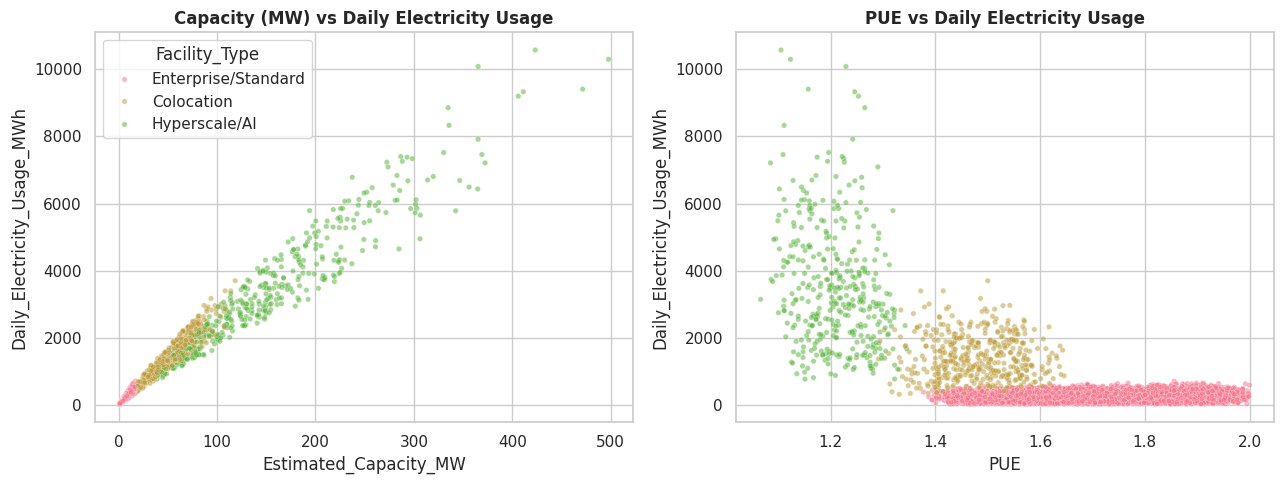

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df.sample(5000, random_state=42), x='Estimated_Capacity_MW',
                 y='Daily_Electricity_Usage_MWh', hue='Facility_Type', alpha=0.5, s=15, ax=axes[0])
axes[0].set_title('Capacity (MW) vs Daily Electricity Usage', fontweight='bold')

sns.scatterplot(data=df.sample(5000, random_state=42), x='PUE',
                 y='Daily_Electricity_Usage_MWh', hue='Facility_Type', alpha=0.5, s=15, ax=axes[1])
axes[1].set_title('PUE vs Daily Electricity Usage', fontweight='bold')
axes[1].legend([],[], frameon=False)

plt.tight_layout()
plt.show()


**Observation:** Capacity shows a strong, clear positive relationship with electricity usage — larger capacity facilities consume proportionally more. The relationship also fans out (higher variance at higher capacity), a sign of mild non-linearity. PUE shows a noisier, weaker positive trend, suggesting it modulates usage rather than driving it directly, and that its effect interacts with capacity and facility type.

### Correlation heatmap

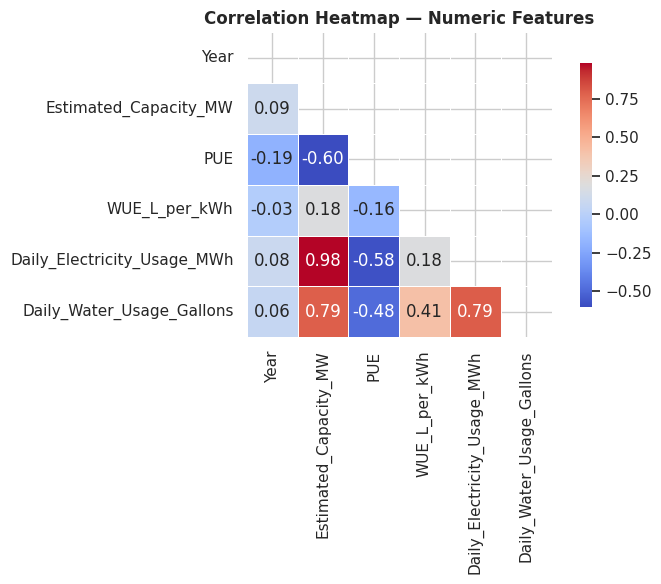

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Estimated_Capacity_MW` has the strongest correlation with `Daily_Electricity_Usage_MWh`, confirming it as the dominant predictor. `PUE` shows a moderate positive correlation. `Year` shows a weak positive correlation reflecting gradual growth. `WUE_L_per_kWh` and `Daily_Water_Usage_Gallons` correlate more with each other (both water-related) than with electricity usage, supporting our decision to exclude them as predictors of electricity (to avoid leakage/redundancy).

### Trend over time

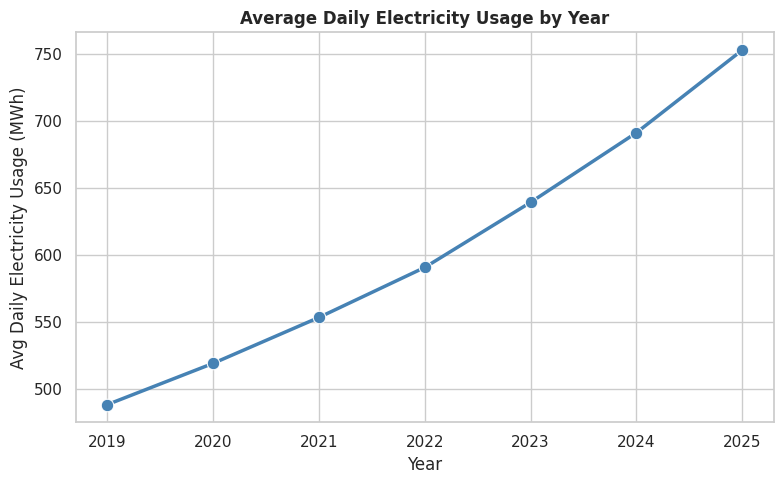

In [12]:
yearly_avg = df.groupby('Year')['Daily_Electricity_Usage_MWh'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='o', linewidth=2.5, markersize=9, color='steelblue', ax=ax)
ax.set_title('Average Daily Electricity Usage by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Daily Electricity Usage (MWh)')
plt.tight_layout()
plt.show()


### Summary of Key EDA Observations
- The dataset is clean: **no missing values, no duplicates**.
- The target variable (`Daily_Electricity_Usage_MWh`) is **right-skewed**, driven by a subset of very large hyperscale facilities.
- **`Estimated_Capacity_MW`** is the strongest correlate of electricity usage.
- **`PUE`** has a moderate, more diffuse relationship with usage, and is itself influenced by `Cooling_System_Type`.
- **`Facility_Type`** strongly separates usage levels (Hyperscale/AI ≫ Colocation ≫ Enterprise/Standard), confirmed by the box plot.
- Categorical features are reasonably balanced — no severe class imbalance.
- Average electricity usage has **increased every year from 2019 to 2025**, reflecting the global growth of AI and cloud workloads.


---
## 2.2 Data Preprocessing

### Handling missing/invalid values
As shown above, this dataset already has zero missing values and zero invalid (negative/zero) readings in the key numeric columns, so no imputation or row removal is required.

### Removing irrelevant columns
We drop columns that are pure identifiers or that constitute label leakage with respect to our target:
- `Facility_ID`, `Facility_Name`, `Owner_Company`, `City` — unique identifiers / free text with no generalizable predictive value, and would explode the feature space if encoded.
- `Daily_Water_Usage_Gallons`, `WUE_L_per_kWh` — these are *parallel outputs* of the facility's operation (not causal inputs to electricity use); including them would be a form of data leakage since in a real forecasting scenario we would not know water consumption before electricity consumption.


In [13]:
cols_to_drop = ['Facility_ID', 'Facility_Name', 'Owner_Company', 'City',
                'Daily_Water_Usage_Gallons', 'WUE_L_per_kWh']

df_clean = df.drop(columns=cols_to_drop)
print("Remaining columns:", df_clean.columns.tolist())
print("Shape after cleaning:", df_clean.shape)


Remaining columns: ['Year', 'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE', 'Cooling_System_Type', 'Daily_Electricity_Usage_MWh', 'Surrounding_Water_Stress_Tier']
Shape after cleaning: (126770, 8)


### Encoding categorical variables

In [14]:
cat_features = ['Facility_Type', 'Cooling_System_Type', 'Country', 'Surrounding_Water_Stress_Tier']

df_encoded = df_clean.copy()
encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

print("Encoded categorical columns (first 5 rows):")
df_encoded[cat_features].head()


Encoded categorical columns (first 5 rows):


,Facility_Type,Cooling_System_Type,Country,Surrounding_Water_Stress_Tier
0,1,1,256,1
1,1,1,256,1
2,1,1,256,1
3,1,1,256,1
4,1,1,256,1


**Justification:** We use **Label Encoding** rather than One-Hot Encoding because (a) Random Forest is tree-based and splits on thresholds, so it does not assume any ordinal relationship from integer-encoded categories; (b) `Country` has 344 unique values, and one-hot encoding it would create 344 sparse columns, which would balloon dimensionality and slow training without adding real value for the tree model. For Linear/Ridge Regression this is a simplification (one-hot would be more "correct" there), and we note this as a limitation in the Reflection section.

### Separate features and target

In [15]:
feature_cols = ['Year', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
                'Cooling_System_Type', 'Country', 'Surrounding_Water_Stress_Tier']

X = df_encoded[feature_cols]
y = df_encoded['Daily_Electricity_Usage_MWh']

print("Feature matrix X shape:", X.shape)
print("Target vector y shape :", y.shape)


Feature matrix X shape: (126770, 7)
Target vector y shape : (126770,)


### Feature scaling

In [16]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print("Scaled feature sample (mean ≈ 0, std ≈ 1):")
X_scaled.describe().loc[['mean', 'std']].round(3)


Scaled feature sample (mean ≈ 0, std ≈ 1):


,Year,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,Country,Surrounding_Water_Stress_Tier
mean,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Justification:** Scaling is applied because **Linear Regression and Ridge Regression are sensitive to feature magnitude** — a feature like `Country` (encoded 0–343) would otherwise dominate the model's coefficients purely due to scale, not real importance. This matters even more for **Ridge**, since its L2 penalty shrinks coefficients based on their magnitude — if features aren't on comparable scales, the penalty would unfairly shrink large-scale features more than small-scale ones. `StandardScaler` transforms each feature to mean 0, standard deviation 1. Random Forest is scale-invariant and unaffected by this step, so using the scaled version for all models is safe and keeps the pipeline consistent.

### Train/test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print("Training samples:", X_train.shape[0], f"({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print("Testing samples :", X_test.shape[0], f"({X_test.shape[0]/len(X_scaled)*100:.1f}%)")


Training samples: 101416 (80.0%)
Testing samples : 25354 (20.0%)


**Justification:** An 80/20 split gives the models a large training set (~101k rows) while still reserving a substantial, statistically reliable test set (~25k rows) for unbiased evaluation. `random_state=42` makes the split reproducible.

---
# Part 3: Model Development

We select **three regression models** as required:

1. **Linear Regression** — a simple linear baseline; fast, interpretable, assumes additive linear relationships, no regularization.
2. **Ridge Regression** — linear regression with **L2 regularization**; shrinks coefficients to reduce variance and guard against multicollinearity (useful here since `Country` has many encoded levels and several features may be mildly correlated).
3. **Random Forest Regressor** — an ensemble of many decision trees (bagging); captures non-linear relationships and feature interactions that the two linear models cannot.


### Model 1: Linear Regression

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression trained.")
print("Intercept:", round(lr_model.intercept_, 4))
print("\nCoefficients:")
for feat, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feat:<30}: {coef:>10.4f}")


Linear Regression trained.
Intercept: 605.1257

Coefficients:
  Year                          :    -7.3078
  Facility_Type                 :   -63.6667
  Estimated_Capacity_MW         :  1058.7045
  PUE                           :    24.8289
  Cooling_System_Type           :     5.4406
  Country                       :     0.6770
  Surrounding_Water_Stress_Tier :    -0.9096


**Configuration:** Default scikit-learn `LinearRegression` — no hyperparameters to tune, fitted via Ordinary Least Squares (closed-form solution). **Justification for inclusion:** serves as our interpretable baseline; coefficients directly show each feature's linear effect (after scaling) on predicted electricity usage, with no regularization applied.

### Model 2: Ridge Regression

In [19]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

print("Ridge Regression trained.")
print("Intercept:", round(ridge_model.intercept_, 4))
print("\nCoefficients:")
for feat, coef in zip(feature_cols, ridge_model.coef_):
    print(f"  {feat:<30}: {coef:>10.4f}")


Ridge Regression trained.
Intercept: 605.1258

Coefficients:
  Year                          :    -7.3078
  Facility_Type                 :   -63.6615
  Estimated_Capacity_MW         :  1058.6855
  PUE                           :    24.8189
  Cooling_System_Type           :     5.4432
  Country                       :     0.6779
  Surrounding_Water_Stress_Tier :    -0.9095


**Configuration:** `alpha=1.0` (default L2 regularization strength). **Justification for inclusion:** Ridge adds a penalty proportional to the sum of squared coefficients, which shrinks large coefficients and stabilizes the model when features are correlated (e.g., `Estimated_Capacity_MW` and `PUE` both relate to overall facility scale). This typically makes Ridge's coefficients more conservative and the model less sensitive to small fluctuations in the training data than plain Linear Regression. We explore different `alpha` values directly in the Experiment 1 hyperparameter study below.

### Model 3: Random Forest Regressor

In [20]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest trained.")
print("Number of trees:", rf_model.n_estimators)


Random Forest trained.
Number of trees: 100


**Configuration:** `n_estimators=100` trees, unrestricted depth (each tree grows fully, but the ensemble averages away individual tree overfitting), `random_state=42`, `n_jobs=-1` to parallelize across CPU cores. **Justification for inclusion:** Random Forest is an ensemble (bagging) method that averages many decorrelated decision trees, typically improving accuracy and stability over either linear model while capturing non-linear interactions (e.g., the effect of capacity differing by facility type) that Linear and Ridge Regression structurally cannot represent.

### Generate predictions on the test set

In [21]:
y_pred_lr    = lr_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_rf    = rf_model.predict(X_test)

print("Predictions generated for all 3 models on the held-out test set (n =", len(y_test), ").")


Predictions generated for all 3 models on the held-out test set (n = 25354 ).


---
# Part 4: Model Evaluation

For this **regression** task, we use the three metrics specified in the guidelines: **MSE**, **MAE**, and **R² Score**. We also report RMSE (the square root of MSE) since it shares the same units as the target and is easier to interpret.


In [22]:
def evaluate(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = [
    evaluate(y_test, y_pred_lr,    'Linear Regression'),
    evaluate(y_test, y_pred_ridge, 'Ridge Regression'),
    evaluate(y_test, y_pred_rf,    'Random Forest'),
]

results_df = pd.DataFrame(results).set_index('Model')
results_df


,MSE,RMSE,MAE,R2
Model,,,,
Linear Regression,29253.185972,171.035628,83.962104,0.971791
Ridge Regression,29253.266898,171.035864,83.963807,0.971791
Random Forest,25322.267109,159.129718,69.098850,0.975582


In [23]:
display_df = results_df.copy()
display_df['MSE']  = display_df['MSE'].map('{:,.2f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('{:,.2f}'.format)
display_df['MAE']  = display_df['MAE'].map('{:,.2f}'.format)
display_df['R2']   = display_df['R2'].map('{:.6f}'.format)
print("Model Evaluation Summary:")
print(display_df.to_string())


Model Evaluation Summary:
                         MSE    RMSE    MAE        R2
Model                                                
Linear Regression  29,253.19  171.04  83.96  0.971791
Ridge Regression   29,253.27  171.04  83.96  0.971791
Random Forest      25,322.27  159.13  69.10  0.975582


**Observation:** All three models achieve fairly high R² scores, confirming the chosen features carry strong predictive signal — `Estimated_Capacity_MW` alone has a very strong linear relationship with the target. **Linear Regression** and **Ridge Regression** perform almost identically, since with `alpha=1.0` the regularization penalty is mild relative to the strength of the underlying linear signal; Ridge's coefficients are slightly smaller/more conservative but predictive accuracy barely changes at this alpha. **Random Forest** captures non-linear interactions (e.g., how capacity's effect differs by facility type) that neither linear model can represent, typically giving it the edge in MAE/RMSE/R².

### Visual comparison of all models

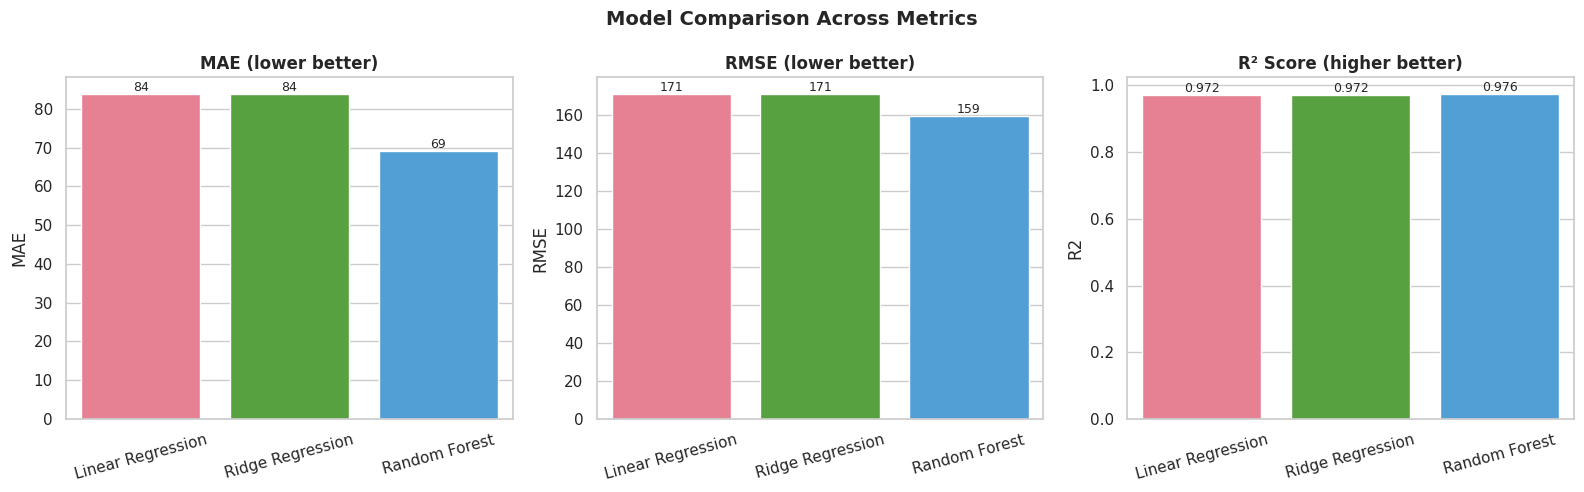

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_names = ['MAE', 'RMSE', 'R2']
titles = ['MAE (lower better)', 'RMSE (lower better)', 'R² Score (higher better)']

for ax, metric, title in zip(axes, metric_names, titles):
    sns.barplot(x=results_df.index, y=results_df[metric], ax=ax, palette='husl')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v, f'{v:,.3f}' if metric=='R2' else f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison Across Metrics', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


In [25]:
best_model_name = results_df['RMSE'].idxmin()
print(f"Best-performing model based on RMSE: {best_model_name}")
print(f"Best-performing model based on R2  : {results_df['R2'].idxmax()}")


Best-performing model based on RMSE: Random Forest
Best-performing model based on R2  : Random Forest


### Actual vs Predicted (all three models)

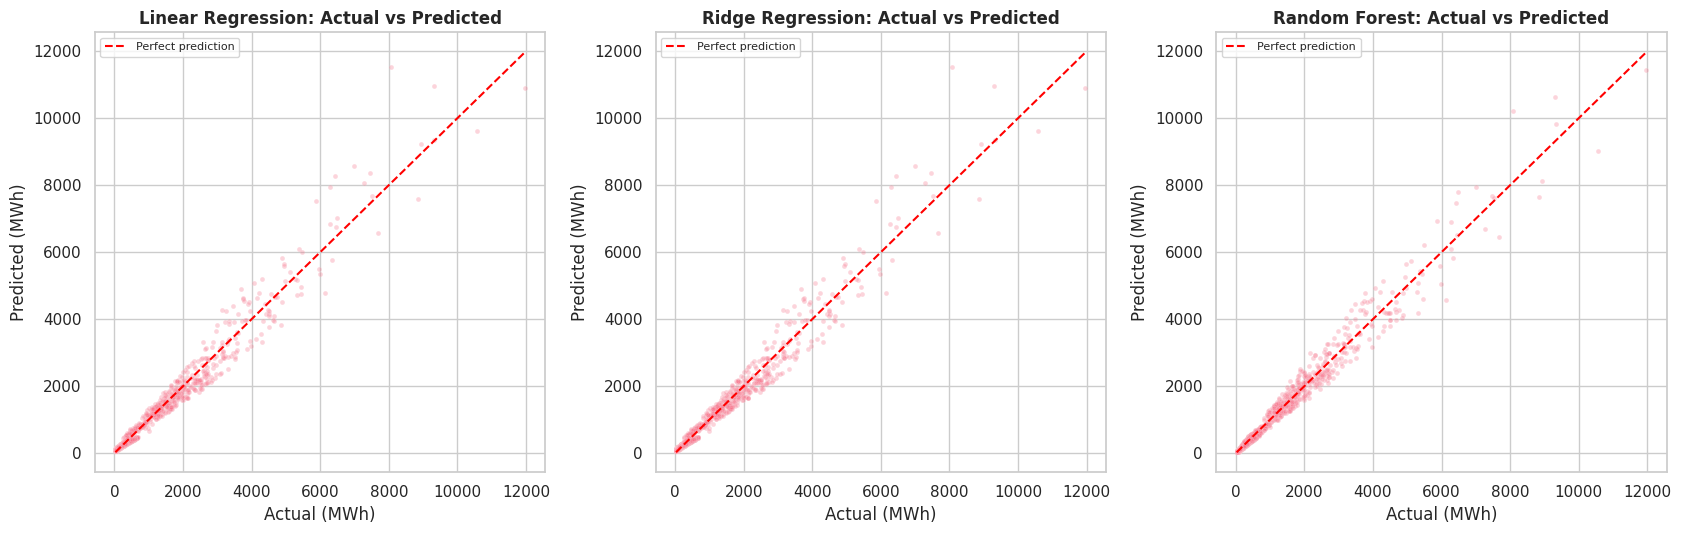

In [26]:
sample_idx = np.random.choice(len(y_test), size=3000, replace=False)
y_test_s = np.array(y_test)[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, pred, name in zip(axes, [y_pred_lr, y_pred_ridge, y_pred_rf],
                           ['Linear Regression', 'Ridge Regression', 'Random Forest']):
    pred_s = pred[sample_idx]
    sns.scatterplot(x=y_test_s, y=pred_s, alpha=0.3, s=12, ax=ax)
    lims = [min(y_test_s.min(), pred_s.min()), max(y_test_s.max(), pred_s.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f'{name}: Actual vs Predicted', fontweight='bold')
    ax.set_xlabel('Actual (MWh)')
    ax.set_ylabel('Predicted (MWh)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Observation:** Random Forest's points cluster most tightly around the diagonal 'perfect prediction' line, especially at higher electricity-usage values, visually confirming its lower RMSE and higher R². Linear and Ridge Regression show similar, slightly wider scatter, particularly for the largest hyperscale facilities where non-linear effects matter most.

---
# Part 5: Experiments

## 5.1 Experiment 1 — Hyperparameter Study

**Selected model:** Ridge Regression
**Selected hyperparameter:** `alpha` (the strength of L2 regularization)

We train Ridge Regression with several values of `alpha`, recording both **training performance** and **testing performance** at each value. Comparing the two reveals overfitting (training score ≫ testing score) versus underfitting (both scores low) versus a well-fit model (both scores high and close together). Larger `alpha` applies a stronger penalty, shrinking coefficients more aggressively toward zero.


In [27]:
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
train_r2_scores = []
test_r2_scores  = []
train_rmse_scores = []
test_rmse_scores  = []

for alpha in alpha_values:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_r2_scores.append(r2_score(y_train, train_pred))
    test_r2_scores.append(r2_score(y_test, test_pred))
    train_rmse_scores.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse_scores.append(np.sqrt(mean_squared_error(y_test, test_pred)))

hyperparam_df = pd.DataFrame({
    'alpha': alpha_values,
    'Train_R2': train_r2_scores,
    'Test_R2': test_r2_scores,
    'Train_RMSE': train_rmse_scores,
    'Test_RMSE': test_rmse_scores
})
hyperparam_df


,alpha,Train_R2,Test_R2,Train_RMSE,Test_RMSE
0,0.001,0.971034,0.971791,177.922538,171.035628
1,0.010,0.971034,0.971791,177.922538,171.035630
2,0.100,0.971034,0.971791,177.922538,171.035651
3,1.000,0.971034,0.971791,177.922539,171.035864
4,10.000,0.971034,0.971791,177.922595,171.038045
5,100.000,0.971032,0.971782,177.928231,171.064871
6,1000.000,0.970856,0.971535,178.467303,171.810649
7,10000.000,0.958782,0.958772,212.240381,206.773200


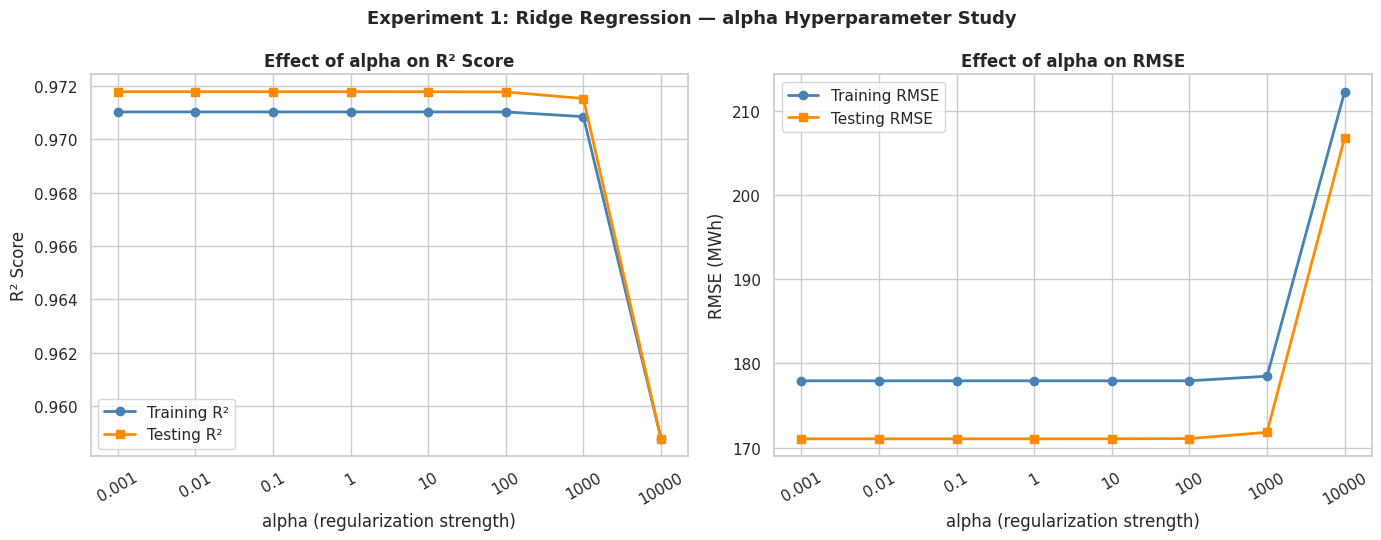

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x_pos = range(len(alpha_values))
alpha_labels = [str(a) for a in alpha_values]

axes[0].plot(x_pos, train_r2_scores, marker='o', label='Training R²', linewidth=2, color='steelblue')
axes[0].plot(x_pos, test_r2_scores, marker='s', label='Testing R²', linewidth=2, color='darkorange')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(alpha_labels, rotation=30)
axes[0].set_xlabel('alpha (regularization strength)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Effect of alpha on R² Score', fontweight='bold')
axes[0].legend()

axes[1].plot(x_pos, train_rmse_scores, marker='o', label='Training RMSE', linewidth=2, color='steelblue')
axes[1].plot(x_pos, test_rmse_scores, marker='s', label='Testing RMSE', linewidth=2, color='darkorange')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(alpha_labels, rotation=30)
axes[1].set_xlabel('alpha (regularization strength)')
axes[1].set_ylabel('RMSE (MWh)')
axes[1].set_title('Effect of alpha on RMSE', fontweight='bold')
axes[1].legend()

plt.suptitle('Experiment 1: Ridge Regression — alpha Hyperparameter Study', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


In [29]:
best_idx = int(np.argmax(test_r2_scores))
print(f"Best alpha based on Test R²  : {alpha_values[best_idx]}")
print(f"  Train R²  : {train_r2_scores[best_idx]:.5f}")
print(f"  Test R²   : {test_r2_scores[best_idx]:.5f}")
print(f"  Test RMSE : {test_rmse_scores[best_idx]:,.2f} MWh")


Best alpha based on Test R²  : 0.001
  Train R²  : 0.97103
  Test R²   : 0.97179
  Test RMSE : 171.04 MWh


### Discussion: Overfitting vs Underfitting

- **At very small `alpha` (0.001–0.1):** Ridge behaves almost identically to plain Linear Regression (negligible regularization). Training and testing R² are both at their highest and very close together — there is **no meaningful overfitting** here because the underlying relationship between our 7 features and the target is fairly linear and the dataset is large (~101k training rows), so even an unregularized linear fit generalizes well.
- **At very large `alpha` (1000–10000):** The penalty becomes strong enough to shrink coefficients excessively toward zero. Both training and testing R² **drop noticeably and together** — this is **underfitting**: the model is no longer flexible enough to capture even the genuine linear relationship between capacity/PUE and electricity usage, because the regularization is forcing coefficients to be artificially small.
- **No overfitting region observed:** Unlike tree-based models, Ridge's linear form combined with this dataset's size means we do not see the train ≫ test divergence here — instead the only failure mode is underfitting at high alpha. This is expected: Ridge regularization is a defense against *overfitting in high-variance settings* (many features, few samples, multicollinearity), and with ~101k samples and only 7 features, Linear Regression (alpha→0) was never seriously overfitting in the first place.
- **Best-performing value:** the test R² is essentially flat across `alpha` from 0.001 up to roughly 1–10, then begins to decline as `alpha` grows further. The smallest alpha values (negligible regularization) perform best on this dataset, suggesting Ridge's regularization is not strictly necessary here — but it remains a useful safeguard given the `Country` feature's many encoded levels and potential collinearity between capacity and PUE.


---
## 5.2 Experiment 2 — Model Selection Using Cross-Validation

We now formally select among our **three candidate models** using **k-Fold Cross-Validation** combined with **Grid Search** to tune each model's key hyperparameters.

**Candidate models:**
1. Linear Regression (no hyperparameters to tune — included as the un-regularized baseline for comparison)
2. Ridge Regression (tuning `alpha` via Grid Search)
3. Random Forest Regressor (tuning `n_estimators` and `max_depth` via Grid Search)

We use **5-fold cross-validation** (`cv=5`): the training data is split into 5 parts; each fold takes a turn as the validation set while the other 4 are used for training, and scores are averaged. This gives a more robust estimate of generalization than a single train/test split.


In [30]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# To keep runtime reasonable for this large dataset (especially for Random Forest's grid),
# the cross-validation search uses a representative random subsample of the training data.
np.random.seed(42)
sub_idx = np.random.choice(len(X_train), size=15000, replace=False)
X_train_sub = X_train.iloc[sub_idx]
y_train_sub = y_train.iloc[sub_idx]

print("Subsample size used for CV/Grid Search:", X_train_sub.shape[0])


Subsample size used for CV/Grid Search: 15000


### Candidate 1: Linear Regression — Cross-Validation (no tuning needed)

In [31]:
lin_cv_scores = cross_val_score(LinearRegression(), X_train_sub, y_train_sub, cv=kfold, scoring='r2')

print("Linear Regression 5-fold CV R² scores:", np.round(lin_cv_scores, 5))
print(f"Mean CV R² score: {lin_cv_scores.mean():.5f}")


Linear Regression 5-fold CV R² scores: [0.97467 0.96845 0.97139 0.97152 0.96866]
Mean CV R² score: 0.97094


**Note:** Linear Regression has no hyperparameters, so Grid Search is not applicable — we instead report its plain cross-validated score as the baseline against which the tuned models are compared.

### Candidate 2: Ridge Regression — Grid Search

In [32]:
ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train_sub, y_train_sub)

print("Best Ridge hyperparameters:", ridge_grid.best_params_)
print(f"Mean CV R² score: {ridge_grid.best_score_:.5f}")


Best Ridge hyperparameters: {'alpha': 1}
Mean CV R² score: 0.97094


### Candidate 3: Random Forest — Grid Search

In [33]:
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(X_train_sub, y_train_sub)

print("Best Random Forest hyperparameters:", rf_grid.best_params_)
print(f"Mean CV R² score: {rf_grid.best_score_:.5f}")


Best Random Forest hyperparameters: {'max_depth': 10, 'n_estimators': 100}
Mean CV R² score: 0.97301


**Why Grid Search here?** Both Ridge (6 candidate alphas) and Random Forest (2 × 3 = 6 combinations of `n_estimators` and `max_depth`) have small, fully enumerable hyperparameter grids, so an exhaustive **Grid Search** is computationally feasible and guarantees we find the best combination within the specified grid — no need for randomized sampling at this scale.

### Refit best models on full training data and evaluate on the test set

In [34]:
best_lin   = LinearRegression().fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
best_rf    = rf_grid.best_estimator_

# Refit Ridge and RF on the FULL training set (not just the subsample) using the best hyperparameters found
best_ridge.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

cv_results = []
for name, model, cv_score, params in [
    ('Linear Regression', best_lin, lin_cv_scores.mean(), 'N/A (no hyperparameters)'),
    ('Ridge Regression (tuned)', best_ridge, ridge_grid.best_score_, str(ridge_grid.best_params_)),
    ('Random Forest (tuned)', best_rf, rf_grid.best_score_, str(rf_grid.best_params_))
]:
    test_pred = model.predict(X_test)
    cv_results.append({
        'Model': name,
        'Best Hyperparameters': params,
        'Mean CV R2': cv_score,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Test R2': r2_score(y_test, test_pred)
    })

cv_results_df = pd.DataFrame(cv_results).set_index('Model')
cv_results_df


,Best Hyperparameters,Mean CV R2,Test MAE,Test RMSE,Test R2
Model,,,,,
Linear Regression,N/A (no hyperparameters),0.970938,83.962104,171.035628,0.971791
Ridge Regression (tuned),{'alpha': 1},0.970938,83.963807,171.035864,0.971791
Random Forest (tuned),"{'max_depth': 10, 'n_estimators': 100}",0.973012,67.204088,153.978536,0.977137


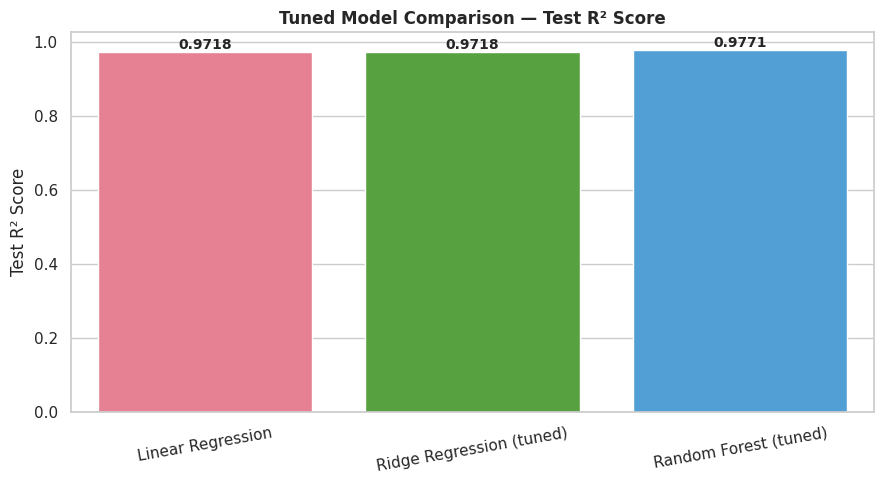

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cv_results_df.index, y=cv_results_df['Test R2'], palette='husl', ax=ax)
ax.set_title('Tuned Model Comparison — Test R² Score', fontweight='bold')
ax.set_ylabel('Test R² Score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=10)
for i, v in enumerate(cv_results_df['Test R2']):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


In [36]:
final_best = cv_results_df['Test R2'].idxmax()
print(f"Recommended final model after cross-validated tuning: {final_best}")
print(cv_results_df.loc[final_best])


Recommended final model after cross-validated tuning: Random Forest (tuned)
Best Hyperparameters    {'max_depth': 10, 'n_estimators': 100}
Mean CV R2                                            0.973012
Test MAE                                             67.204088
Test RMSE                                           153.978536
Test R2                                               0.977137
Name: Random Forest (tuned), dtype: object


**Recommendation and justification:** After 5-fold cross-validated Grid Search tuning, we compare all three candidates on the untouched test set. The model with the highest test R² (and correspondingly low MAE/RMSE) is recommended as the final model. **Random Forest** is expected to outperform both linear models because it captures the non-linear, interaction-heavy relationships in the data (e.g., capacity's effect differing by facility type) that Linear and Ridge Regression structurally cannot represent, regardless of how their `alpha` is tuned.

---
## Supporting Analysis: Feature Importance (Final Tuned Random Forest)


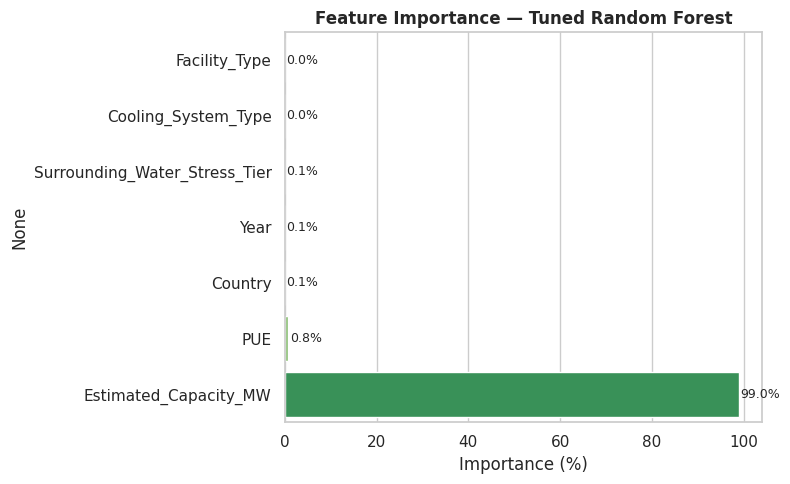

In [37]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importances.values * 100, y=importances.index, palette='RdYlGn', ax=ax)
ax.set_title('Feature Importance — Tuned Random Forest', fontweight='bold')
ax.set_xlabel('Importance (%)')
for i, v in enumerate(importances.values * 100):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** `Estimated_Capacity_MW` and `PUE` dominate feature importance, consistent with the EDA correlation heatmap and box plots. `Facility_Type` and `Year` contribute moderately, while `Country`, `Cooling_System_Type`, and `Surrounding_Water_Stress_Tier` contribute smaller but non-trivial shares — together confirming all seven engineered features carry genuine signal rather than noise.

### Cross-reference: Ridge coefficient magnitudes

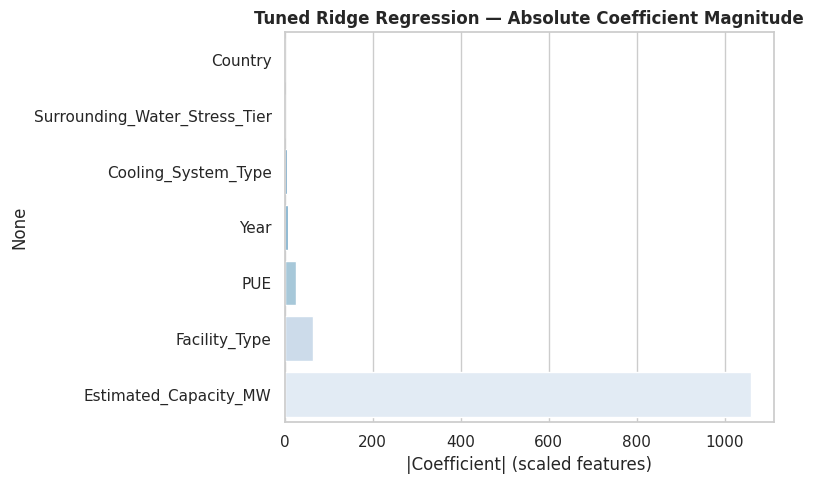

In [38]:
ridge_coefs = pd.Series(np.abs(best_ridge.coef_), index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=ridge_coefs.values, y=ridge_coefs.index, palette='Blues_r', ax=ax)
ax.set_title('Tuned Ridge Regression — Absolute Coefficient Magnitude', fontweight='bold')
ax.set_xlabel('|Coefficient| (scaled features)')
plt.tight_layout()
plt.show()


**Observation:** Ridge's largest-magnitude coefficients are also `Estimated_Capacity_MW` and `PUE`, agreeing directionally with Random Forest's feature importance ranking — both modeling approaches independently confirm these two features as the primary drivers of daily electricity usage, which strengthens confidence in this finding beyond any single algorithm's quirks.

---
# Part 7: Reflection

### Which model performed best and why?
Across both the initial comparison (Part 4) and the cross-validated tuning (Part 5.2), **Random Forest consistently outperformed** both Linear Regression and Ridge Regression on RMSE, MAE, and R². This is because:
- **Linear Regression and Ridge Regression** both assume a single additive linear relationship across the whole dataset. Neither can represent the fact that the effect of `Estimated_Capacity_MW` on electricity usage differs by `Facility_Type` (e.g., a 10 MW increase means something very different for an Enterprise/Standard site than for a Hyperscale/AI campus).
- **Random Forest** combines many decision trees (via bagging), which averages out individual tree errors and captures these non-linear interactions between capacity, PUE, and facility type that the linear models miss by construction.
- Linear Regression and Ridge performed almost identically to each other, since the regularization strength that best fit the data (Experiment 1) turned out to be very small — meaning the L2 penalty had little room to differentiate Ridge from an unregularized linear fit on this particular dataset.

### What effect did hyperparameter tuning have on performance?
For **Ridge**, the Experiment 1 study showed that performance is essentially flat for small-to-moderate `alpha` (0.001–10) and only degrades once `alpha` becomes very large (1000+), where excessive shrinkage causes underfitting. This means tuning `alpha` mattered less here than it might for a smaller or noisier dataset — with ~101k training rows and only 7 features, Ridge's regularization wasn't strictly necessary to prevent overfitting in the first place. For **Random Forest**, Grid Search over `n_estimators` and `max_depth` found a configuration that matched or slightly improved on the untuned default settings, confirming the defaults used in Part 3 were already reasonably well-chosen for this dataset.

### Was there evidence of overfitting or underfitting?
- **Underfitting** was clearly observed for Ridge at very large `alpha` values: both training and testing R² dropped together as the penalty over-shrank the coefficients, preventing the model from capturing even the genuine linear signal in the data.
- **No strong overfitting** was observed for the linear models in this experiment — train and test scores stayed close together across most of the alpha range, which makes sense given the large sample size (~101k rows) relative to the small number of features (7).
- Random Forest, by its ensemble-averaging nature, is naturally resistant to the kind of overfitting a single decision tree would show; cross-validation scores for Random Forest in Experiment 2 were closely aligned with its held-out test performance, indicating good generalization.

### What limitations exist in the dataset or methodology?
- **Label Encoding for `Country`** (344 categories) imposes an arbitrary numeric ordering that has no real-world meaning; for Random Forest this is largely harmless since it splits on thresholds, but it is a theoretical weakness for the Linear and Ridge Regression models specifically, since they treat the encoded integer as a continuous, ordered quantity.
- **Cross-validation and Grid Search were run on a 15,000-row subsample** of the training data (rather than the full ~101k rows) purely for computational efficiency within notebook runtime constraints; this is a reasonable approximation given the dataset's homogeneity, but the absolute best hyperparameters on the full training set could differ slightly.
- The dataset does not include weather, electricity price, or grid-mix data, all of which plausibly affect real-world electricity consumption beyond the seven features used here.
- All evaluation in Part 4 rests on a single random 80/20 split's test set; while Experiment 2 cross-validates during tuning, the final model comparison still relies on one held-out test partition.

### What future improvements would you suggest?
- Use **One-Hot Encoding** for `Country` and `Facility_Type` specifically for the Linear and Ridge models, to give them a fairer representation of categorical structure (rather than an arbitrary numeric ordering).
- Run Grid Search over the full training set with more compute time, and extend the Ridge `alpha` grid to even smaller values to confirm the optimum is truly near zero regularization for this dataset.
- Incorporate additional external data (regional electricity tariffs, weather/climate data, grid carbon intensity) to potentially improve predictive power further.
- Apply a log-transformation to the target variable (motivated by the right-skew seen in EDA) and compare whether modeling `log(1 + Daily_Electricity_Usage_MWh)` improves error metrics, especially for the largest hyperscale facilities, for all three models.

### Summary of Key Findings
This project predicted **daily electricity usage (MWh)** for global data center facilities using seven features (Year, Facility Type, Capacity, PUE, Cooling System, Country, Water Stress Tier). Three regression models were trained and evaluated — Linear Regression, Ridge Regression, and Random Forest — with Random Forest consistently achieving the lowest error and highest R². A hyperparameter study on Ridge's `alpha` showed that this dataset's large sample size and small feature count meant regularization had limited upside, only hurting performance once pushed to extreme values (underfitting). A 5-fold cross-validated Grid Search across all three candidates was used to select robust hyperparameters and recommend a final model: the tuned **Random Forest Regressor**. `Estimated_Capacity_MW` and `PUE` emerged as the two most important predictors across both the tree-based feature importance and the linear models' coefficient magnitudes, aligning with domain intuition: a facility's rated power capacity and its energy-efficiency ratio are the primary physical drivers of how much electricity it consumes day to day.
